In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/household_energy_consumption.csv")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df.head()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
0,H00001,2025-04-01,8.4,4.0,17.8,No,3.2
1,H00001,2025-04-02,7.9,4.0,17.3,No,2.8
2,H00001,2025-04-03,9.2,4.0,18.6,No,3.0
3,H00001,2025-04-04,7.9,4.0,18.2,No,2.7
4,H00001,2025-04-05,9.6,4.0,11.9,No,3.2


In [ ]:
df.tail()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
55134,H07877,2025-04-03,5.1,1.0,22.4,Yes,2.1
55135,H07877,2025-04-04,2.8,1.0,16.0,Yes,1.3
55136,H07877,2025-04-05,5.4,1.0,22.0,Yes,2.3
55137,H07877,2025-04-06,4.4,1.0,15.5,Yes,2.0
55138,H0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(55139, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55139 entries, 0 to 55138
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Household_ID            55139 non-null  object 
 1   Date                    55138 non-null  object 
 2   Energy_Consumption_kWh  55138 non-null  float64
 3   Household_Size          55138 non-null  float64
 4   Avg_Temperature_C       55138 non-null  float64
 5   Has_AC                  55138 non-null  object 
 6   Peak_Hours_Usage_kWh    55138 non-null  float64
dtypes: float64(4), object(3)
memory usage: 2.9+ MB


In [ ]:
df.describe()

,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Peak_Hours_Usage_kWh
count,55138.000000,55138.000000,55138.000000,55138.000000
mean,10.655807,3.508107,17.511845,4.360428
std,5.523784,1.709909,2.494603,2.537259
min,0.500000,1.000000,10.000000,0.200000
25%,6.000000,2.000000,15.800000,2.300000
50%,10.400000,4.000000,17.500000,4.000000
75%,14.900000,5.000000,19.200000,6.000000
max,20.000000,6.000000,25.000000,10.000000


In [ ]:
df.dtypes

,0
Household_ID,object
Date,object
Energy_Consumption_kWh,float64
Household_Size,float64
Avg_Temperature_C,float64
Has_AC,object
Peak_Hours_Usage_kWh,float64


In [ ]:
df.columns

Index(['Household_ID', 'Date', 'Energy_Consumption_kWh', 'Household_Size',
       'Avg_Temperature_C', 'Has_AC', 'Peak_Hours_Usage_kWh'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Household_ID,0
Date,1
Energy_Consumption_kWh,1
Household_Size,1
Avg_Temperature_C,1
Has_AC,1
Peak_Hours_Usage_kWh,1


In [ ]:
df=df.dropna()

In [ ]:
x=df[["Household_Size", "Avg_Temperature_C", "Peak_Hours_Usage_kWh"]]
y=df["Energy_Consumption_kWh"]

In [ ]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42)

In [ ]:
poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)

In [ ]:
model=LinearRegression()
model.fit(x_train_poly, y_train)

LinearRegression()

In [ ]:
y_pred= model.predict(x_test_poly)

In [ ]:
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
rmse=mse **0.5
r2=r2_score(y_test, y_pred)

In [ ]:
print("\nPolynomial Regression Results")
print("-----------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 :", r2)


Polynomial Regression Results
-----------------
MAE : 0.5733849143921317
MSE : 0.5305277005015957
RMSE : 0.7283733249519753
R2 : 0.9826557247754106


In [ ]:
result=pd.DataFrame({
    "Actual Energy": y_test.values,
    "Predicted Energy": y_pred
})
print("\nActual vs Predicted:")
print(result.head(10))


Actual vs Predicted:
   Actual Energy  Predicted Energy
0           11.6         11.797831
1           14.1         13.760530
2            6.9          7.640367
3            4.7          4.409087
4            7.4          6.889771
5            7.5          7.104188
6            5.7          5.929669
7            3.8          3.849876
8            0.7          0.800857
9           15.2         13.228983


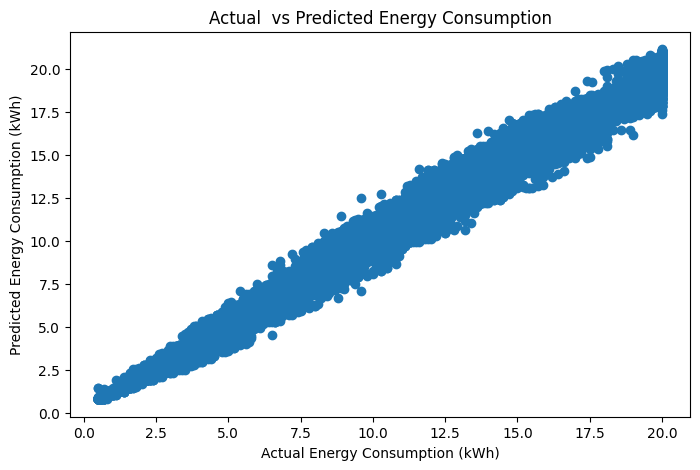

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Energy Consumption (kWh)")
plt.ylabel("Predicted Energy Consumption (kWh)")
plt.title("Actual  vs Predicted Energy Consumption")
plt.show()